## 1. Data Exploration

### `01_dataset_exploration.ipynb`

Exploring Le2i Fall Detection Dataset...
Found 190 fall videos
Video: video (1).avi
Total frames: 157
FPS: 25.00
Duration: 6.28 seconds


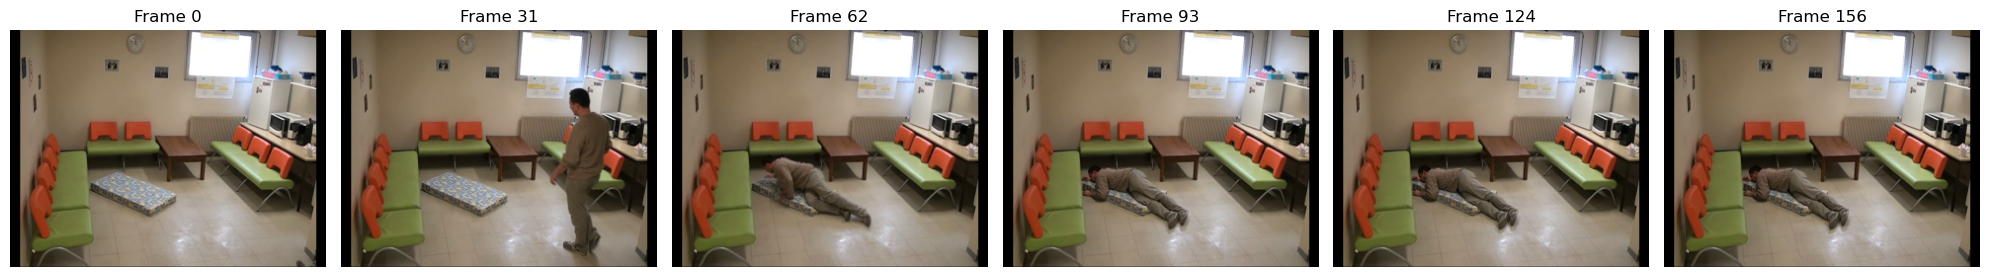

Video: video (10).avi
Total frames: 362
FPS: 25.00
Duration: 14.48 seconds


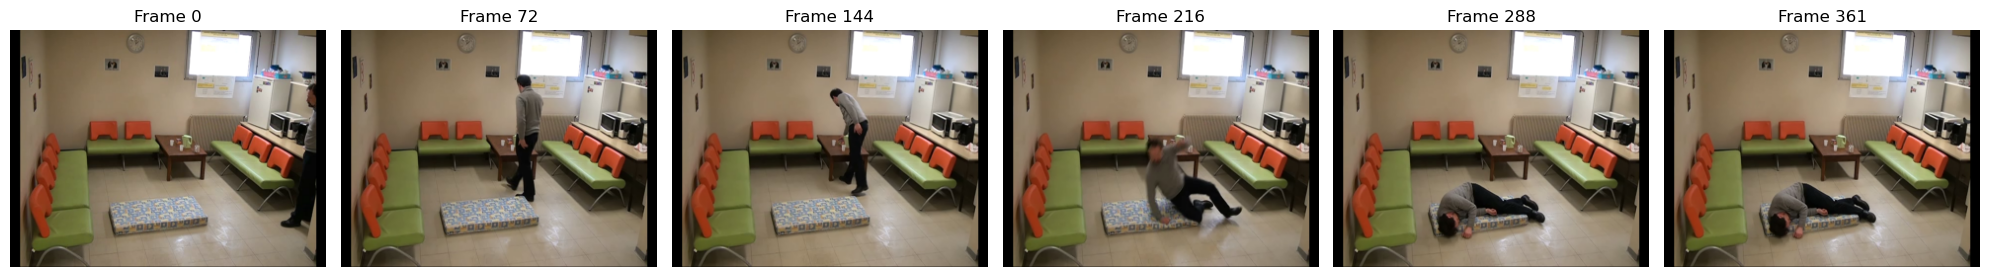

Video: video (11).avi
Total frames: 483
FPS: 25.00
Duration: 19.32 seconds


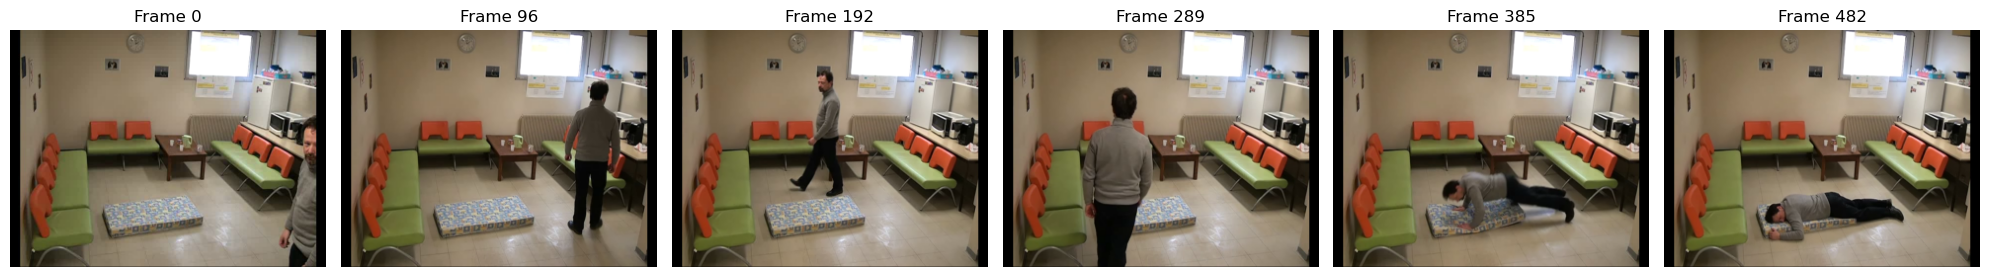


Exploring Workout Videos Dataset...
Found 190 workout videos


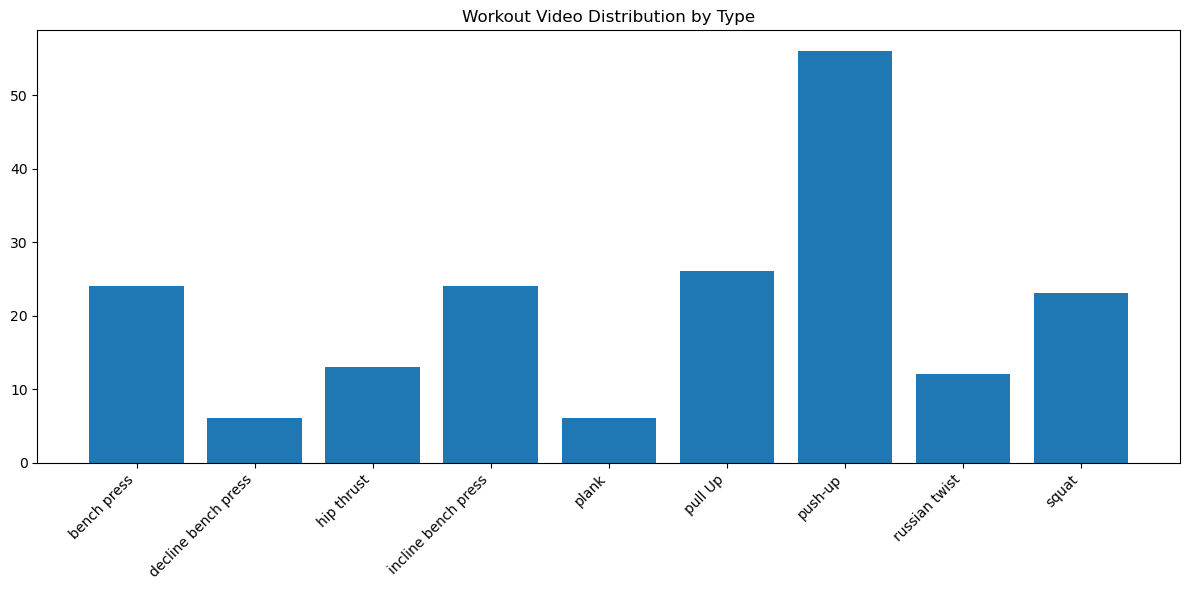

Video: bench press_1.mp4
Total frames: 58
FPS: 29.97
Duration: 1.94 seconds


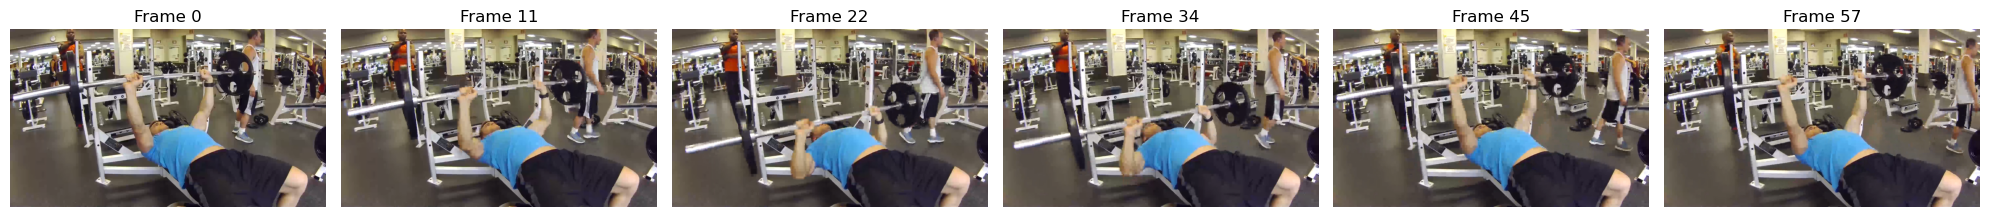

Video: bench press_10.mp4
Total frames: 53
FPS: 29.97
Duration: 1.77 seconds


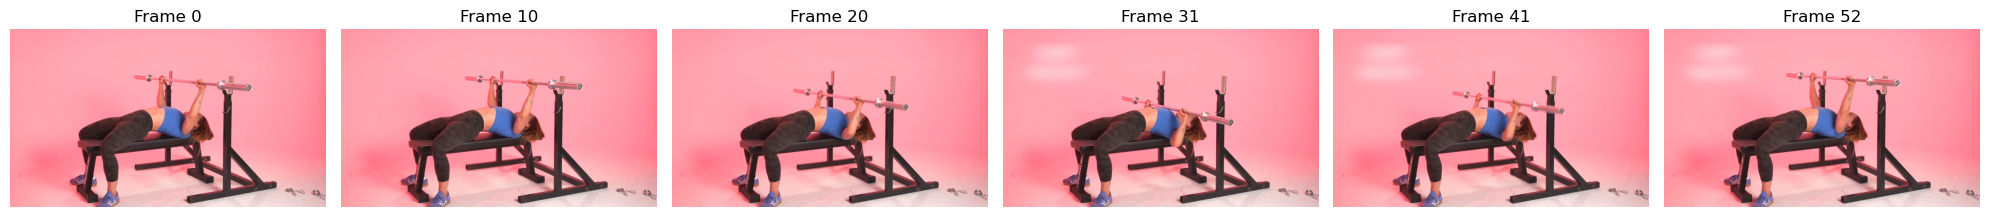

Video: bench press_11.mp4
Total frames: 39
FPS: 29.97
Duration: 1.30 seconds


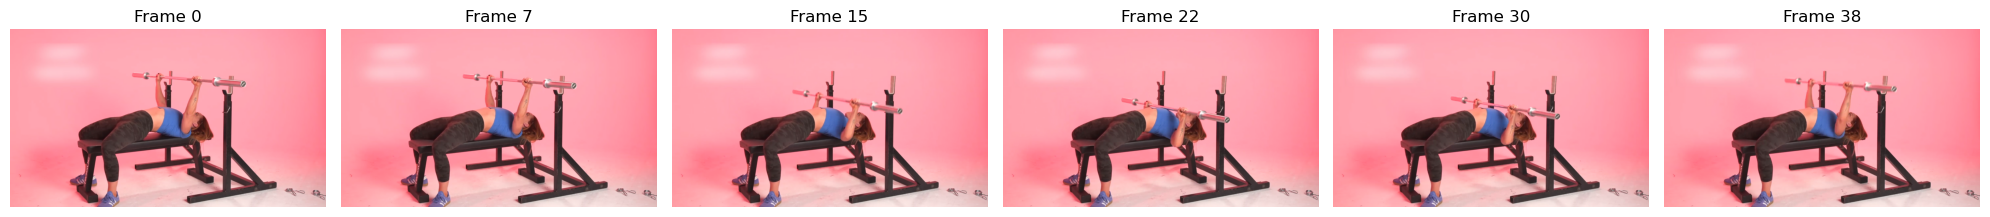


Analyzing Video Statistics...
Analyzing 380 videos...

Video Dataset Summary:
Total videos: 380
Fall videos: 190
Workout videos: 190

Duration Statistics (seconds):
            min         max       mean     median
dataset                                          
fall     5.3200   78.160000  16.108379  11.285743
workout  1.3013  228.033333   7.909341   5.005000

Common Resolutions:
resolution
320x240      166
1920x1080    102
1280x720      84
320x180       25
1080x608       1
Name: count, dtype: int64

FPS Statistics:
               min   max       mean    median
dataset                                      
fall     24.000384  25.0  24.684332  25.00000
workout  23.976043  60.0  28.957934  29.97003


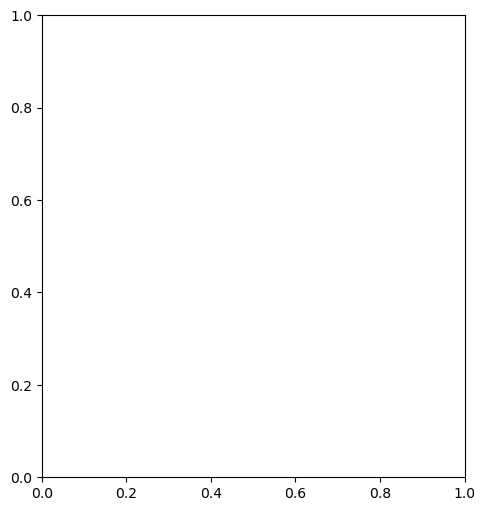

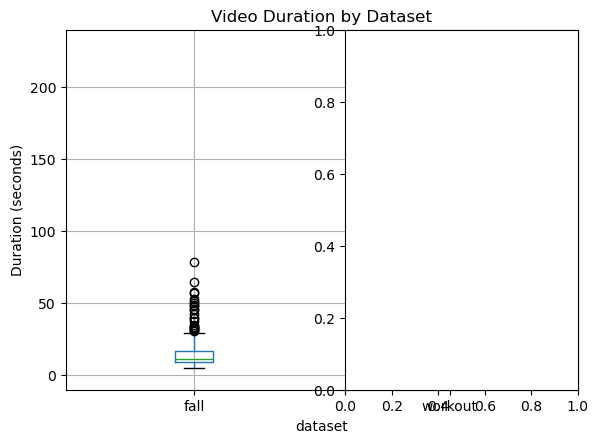

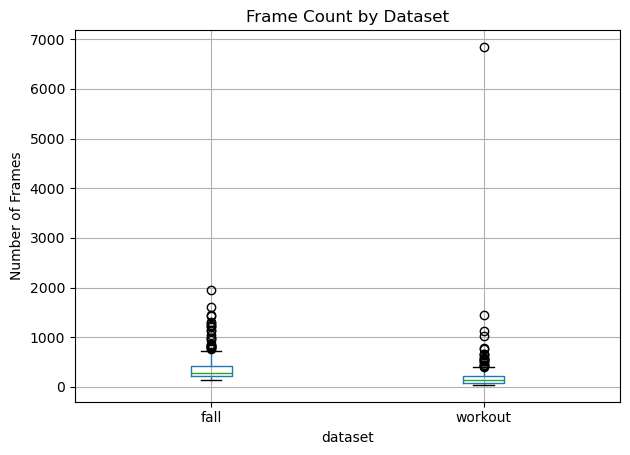


Dataset exploration complete!


In [1]:
# 01_dataset_exploration.ipynb - Video Only Version
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set paths to your datasets - only videos
FALL_DATA_DIR = "../../data/le2i"
WORKOUT_VIDEOS_DIR = "../../data/workout_videos"
# Remove image directories that were causing errors

# Function to display video frames
def display_video_frames(video_path, num_frames=6):
    """Display sample frames from a video"""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return
        
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = frame_count / fps
    
    print(f"Video: {os.path.basename(video_path)}")
    print(f"Total frames: {frame_count}")
    print(f"FPS: {fps:.2f}")
    print(f"Duration: {duration:.2f} seconds")
    
    # Get evenly spaced frame indices
    indices = np.linspace(0, frame_count-1, num_frames, dtype=int)
    
    # Create a figure to display frames
    fig, axes = plt.subplots(1, num_frames, figsize=(20, 4))
    
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame)
            axes[i].set_title(f"Frame {idx}")
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    cap.release()

# Function to safely find files with error handling
def find_videos(directory, extensions):
    """Find video files with specified extensions in directory"""
    if not os.path.exists(directory):
        print(f"Warning: Directory {directory} not found.")
        return []
        
    videos = []
    for ext in extensions:
        try:
            videos.extend(list(Path(directory).rglob(f"*{ext}")))
        except Exception as e:
            print(f"Error finding {ext} files in {directory}: {e}")
    
    return videos

# 1. Explore Fall Videos
print("Exploring Le2i Fall Detection Dataset...")
fall_videos = find_videos(FALL_DATA_DIR, [".avi", ".mp4"])
print(f"Found {len(fall_videos)} fall videos")

# Display sample fall videos
if fall_videos:
    for i in range(min(3, len(fall_videos))):
        display_video_frames(str(fall_videos[i]))

# 2. Explore Workout Videos
print("\nExploring Workout Videos Dataset...")
workout_videos = find_videos(WORKOUT_VIDEOS_DIR, [".mp4", ".avi"])
print(f"Found {len(workout_videos)} workout videos")

# Count videos by subdirectory (workout type)
workout_types = {}
for video in workout_videos:
    category = video.parent.name
    workout_types[category] = workout_types.get(category, 0) + 1

# Display workout type distribution
if workout_types:
    plt.figure(figsize=(12, 6))
    plt.bar(workout_types.keys(), workout_types.values())
    plt.title('Workout Video Distribution by Type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Display sample workout videos
if workout_videos:
    for i in range(min(3, len(workout_videos))):
        display_video_frames(str(workout_videos[i]))

# 3. Analyze video statistics
print("\nAnalyzing Video Statistics...")

# Function to get video statistics
def get_video_stats(video_path):
    """Get basic statistics for a video file"""
    # Convert string to Path object if it's not already
    if isinstance(video_path, str):
        video_path = Path(video_path)
    
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
        
    stats = {
        'path': str(video_path),
        'filename': video_path.name,
        'category': video_path.parent.name,
        'frames': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        'width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        'fps': cap.get(cv2.CAP_PROP_FPS),
    }
    
    stats['duration'] = stats['frames'] / stats['fps'] if stats['fps'] > 0 else 0
    stats['resolution'] = f"{stats['width']}x{stats['height']}"
    
    cap.release()
    return stats

# Collect statistics for all videos
all_videos = fall_videos + workout_videos
video_stats = []

print(f"Analyzing {len(all_videos)} videos...")
for video in all_videos:
    stats = get_video_stats(video)  # Pass Path object directly
    if stats:
        # Add dataset type (fall or workout)
        if video in fall_videos:
            stats['dataset'] = 'fall'
        else:
            stats['dataset'] = 'workout'
        video_stats.append(stats)

# Create DataFrame
if video_stats:
    stats_df = pd.DataFrame(video_stats)
    
    # Display summary statistics
    print("\nVideo Dataset Summary:")
    print(f"Total videos: {len(stats_df)}")
    print(f"Fall videos: {len(stats_df[stats_df['dataset'] == 'fall'])}")
    print(f"Workout videos: {len(stats_df[stats_df['dataset'] == 'workout'])}")
    
    # Duration statistics
    print("\nDuration Statistics (seconds):")
    duration_by_dataset = stats_df.groupby('dataset')['duration'].agg(['min', 'max', 'mean', 'median'])
    print(duration_by_dataset)
    
    # Resolution statistics
    print("\nCommon Resolutions:")
    resolution_counts = stats_df['resolution'].value_counts()
    print(resolution_counts.head(5))
    
    # FPS statistics
    print("\nFPS Statistics:")
    fps_by_dataset = stats_df.groupby('dataset')['fps'].agg(['min', 'max', 'mean', 'median'])
    print(fps_by_dataset)
    
    # Plot duration distribution
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    stats_df.boxplot(column='duration', by='dataset')
    plt.title('Video Duration by Dataset')
    plt.suptitle('')  # Remove pandas-generated title
    plt.ylabel('Duration (seconds)')
    
    plt.subplot(1, 2, 2)
    stats_df.boxplot(column='frames', by='dataset')
    plt.title('Frame Count by Dataset')
    plt.suptitle('')
    plt.ylabel('Number of Frames')
    
    plt.tight_layout()
    plt.show()
else:
    print("No video statistics available.")

print("\nDataset exploration complete!")